# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

# Individual Homework 05 — Applied Security Audit on COMPAS

## Setup · Cell 1: Imports, Data Loading, and Model Training

We reuse the same COMPAS preprocessing logic from lecture and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) models.


In [9]:
# Imports, Data Loading, Model Training
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display, Markdown
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

THR = 0.5
RANDOM_STATE = 42
PROTECTED_GROUP = "African-American"
REFERENCE_GROUP = "Caucasian"
FAIR_LOW, FAIR_HIGH = 0.80, 1.25

# Load COMPAS dataset
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "sex",
]
TARGET = "two_year_recid"

df_m = df[FEATURES + [TARGET, "race"]].dropna().copy()
df_m = pd.get_dummies(df_m, columns=["c_charge_degree", "sex"], drop_first=True)

X = df_m.drop(columns=[TARGET, "race"]).astype(float)
y = df_m[TARGET].astype(int).values
race = df_m["race"].astype(str).values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

sc = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=RANDOM_STATE,
).fit(Xs_tr, y_tr)

model_specs = {"LR": lr, "GBT": gbt}

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1]):.3f}")


def positive_scores(model, X_scaled):
    return model.predict_proba(X_scaled)[:, 1]


def binary_predictions(model, X_scaled, threshold=THR):
    return (positive_scores(model, X_scaled) >= threshold).astype(int)


def fpr_by_group(y_true, y_pred_binary, groups):
    mask = np.asarray(y_true) == 0
    return (
        pd.DataFrame({"pred": np.asarray(y_pred_binary)[mask], "group": np.asarray(groups)[mask]})
        .groupby("group")["pred"]
        .mean()
    )


def air(fpr_ref, fpr_prot):
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan


def air_from_series(fpr_series, protected=PROTECTED_GROUP, reference=REFERENCE_GROUP):
    return air(fpr_series.get(reference, np.nan), fpr_series.get(protected, np.nan))


Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


## Setup · Cell 2: Clean-Model Fairness Baseline

Before any attack, we establish the **clean baseline** for:
- **Train AUC** and **Test AUC**
- **FPR by race**
- **AIR = FPR_African-American / FPR_Caucasian**

These baseline values are reused in every later part.


In [19]:
# Clean-Model Fairness Baseline

baseline_rows = []
for model_name, model in model_specs.items():
    pred = binary_predictions(model, Xs_te)
    fpr = fpr_by_group(y_te, pred, r_te)
    baseline_rows.append(
        {
            "model": model_name,
            "train_AUC": roc_auc_score(y_tr, positive_scores(model, Xs_tr)),
            "test_AUC": roc_auc_score(y_te, positive_scores(model, Xs_te)),
            "generalization_gap": roc_auc_score(y_tr, positive_scores(model, Xs_tr))
            - roc_auc_score(y_te, positive_scores(model, Xs_te)),
            "FPR_African-American": fpr.get(PROTECTED_GROUP, np.nan),
            "FPR_Caucasian": fpr.get(REFERENCE_GROUP, np.nan),
            "AIR": air_from_series(fpr),
        }
    )

baseline_summary = pd.DataFrame(baseline_rows)
display(baseline_summary.round(3))

baseline_lr_fpr = fpr_by_group(y_te, binary_predictions(lr, Xs_te), r_te)
BASELINE_LR_AA = baseline_lr_fpr.get(PROTECTED_GROUP, np.nan)
BASELINE_LR_CA = baseline_lr_fpr.get(REFERENCE_GROUP, np.nan)
BASELINE_LR_AIR = air_from_series(baseline_lr_fpr)

,model,train_AUC,test_AUC,generalization_gap,FPR_African-American,FPR_Caucasian,AIR
0,LR,0.727,0.735,-0.008,0.281,0.143,1.961
1,GBT,0.798,0.718,0.080,0.317,0.178,1.782


**Baseline interpretation**

The clean LR AIR is 1.961. These clean values provide the reference point for the PGD and poisoning comparisons below.

## Part 1 · PGD Evasion Audit

Run the PGD attack across `epsilon ∈ {0.25, 0.5, 1.0, 2.0}` on **both LR and GBT**, and for each model / epsilon report:
- **FPR by race**
- **AIR**
- the epsilon at which **AIR crosses 0.80**



,model,epsilon,FPR_African-American,FPR_Caucasian,AIR
0,GBT,0.25,0.317,0.178,1.782
1,GBT,0.50,0.490,0.306,1.600
2,GBT,1.00,0.490,0.306,1.600
3,GBT,2.00,0.490,0.306,1.600
4,LR,0.25,0.526,0.341,1.543
5,LR,0.50,0.755,0.514,1.470
6,LR,1.00,0.955,0.840,1.138
7,LR,2.00,1.000,1.000,1.000



AIR threshold summary


,model,epsilon_where_AIR_lt_0_80,min_AIR_tested
0,GBT,not reached,1.600036
1,LR,not reached,1.000000


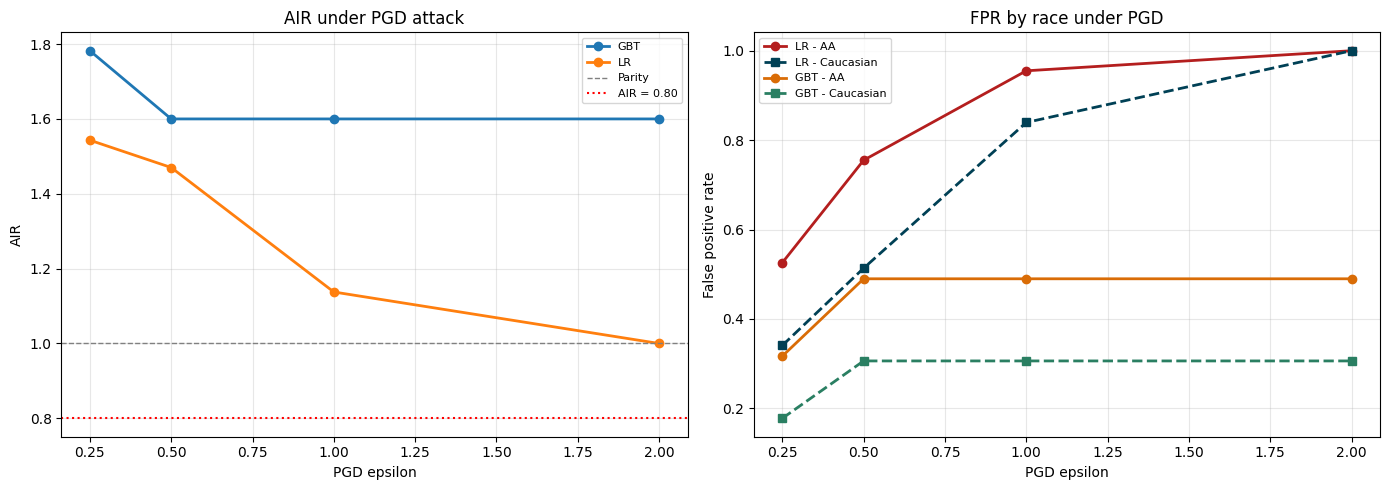


Part 1 comparison summary


,model,avg_AIR_drop,min_tested_AIR,max_FPR_African_American,max_FPR_Caucasian
0,GBT,0.137,1.6,0.49,0.306
1,LR,0.674,1.0,1.00,1.000


In [21]:
# PGD Evasion Audit on LR and GBT

epsilons = [0.25, 0.5, 1.0, 2.0]
feature_lower = Xs_tr.min(axis=0)
feature_upper = Xs_tr.max(axis=0)


def finite_difference_gradient_sign(model, X_current, epsilon):
    delta = max(1e-3, min(0.05, epsilon / 10 if epsilon > 0 else 0.01))
    grad = np.zeros_like(X_current)
    for j in range(X_current.shape[1]):
        plus = X_current.copy()
        minus = X_current.copy()
        plus[:, j] = np.minimum(plus[:, j] + delta, feature_upper[j])
        minus[:, j] = np.maximum(minus[:, j] - delta, feature_lower[j])
        grad[:, j] = (positive_scores(model, plus) - positive_scores(model, minus)) / (2 * delta)
    return np.sign(grad)


def pgd_tabular(model, X_scaled, epsilon, alpha=0.05, n_iter=40):
    X0 = X_scaled.copy()
    X_adv = X0.copy()
    lower = np.maximum(X0 - epsilon, feature_lower)
    upper = np.minimum(X0 + epsilon, feature_upper)

    for _ in range(n_iter):
        if hasattr(model, "coef_"):
            step_sign = np.sign(model.coef_[0])[np.newaxis, :]
        else:
            step_sign = finite_difference_gradient_sign(model, X_adv, epsilon)
        X_adv = X_adv + alpha * step_sign
        X_adv = np.minimum(np.maximum(X_adv, lower), upper)

    return X_adv


pgd_rows = []
for model_name, model in model_specs.items():
    for epsilon in epsilons:
        X_adv = pgd_tabular(model, Xs_te, epsilon=epsilon)
        pred_adv = binary_predictions(model, X_adv)
        fpr_adv = fpr_by_group(y_te, pred_adv, r_te)
        pgd_rows.append(
            {
                "model": model_name,
                "epsilon": epsilon,
                "FPR_African-American": fpr_adv.get(PROTECTED_GROUP, np.nan),
                "FPR_Caucasian": fpr_adv.get(REFERENCE_GROUP, np.nan),
                "AIR": air_from_series(fpr_adv),
            }
        )

pgd_summary = pd.DataFrame(pgd_rows).sort_values(["model", "epsilon"]).reset_index(drop=True)
display(pgd_summary.round(3))

pgd_crossings = []
for model_name, group in pgd_summary.groupby("model"):
    crossed = group[group["AIR"] < FAIR_LOW].sort_values("epsilon")
    pgd_crossings.append(
        {
            "model": model_name,
            "epsilon_where_AIR_lt_0_80": crossed.iloc[0]["epsilon"] if len(crossed) else "not reached",
            "min_AIR_tested": group["AIR"].min(),
        }
    )
pgd_crossings = pd.DataFrame(pgd_crossings)
print("\nAIR threshold summary")
display(pgd_crossings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for model_name, group in pgd_summary.groupby("model"):
    ax.plot(group["epsilon"], group["AIR"], marker="o", linewidth=2, label=model_name)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Parity")
ax.axhline(FAIR_LOW, color="red", linestyle=":", linewidth=1.5, label="AIR = 0.80")
ax.set_xlabel("PGD epsilon")
ax.set_ylabel("AIR")
ax.set_title("AIR under PGD attack")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
styles = {
    ("LR", "FPR_African-American"): ("#B41E1E", "o-"),
    ("LR", "FPR_Caucasian"): ("#004055", "s--"),
    ("GBT", "FPR_African-American"): ("#D96C06", "o-"),
    ("GBT", "FPR_Caucasian"): ("#2A7F62", "s--"),
}
for (model_name, column_name), (color, style) in styles.items():
    subset = pgd_summary[pgd_summary["model"] == model_name]
    ax.plot(
        subset["epsilon"],
        subset[column_name],
        style,
        color=color,
        linewidth=2,
        label=f"{model_name} - {'AA' if 'African' in column_name else 'Caucasian'}",
    )
ax.set_xlabel("PGD epsilon")
ax.set_ylabel("False positive rate")
ax.set_title("FPR by race under PGD")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

baseline_air_lookup = baseline_summary.set_index("model")["AIR"].to_dict()
pgd_analysis = pgd_summary.copy()
pgd_analysis["baseline_AIR"] = pgd_analysis["model"].map(baseline_air_lookup)
pgd_analysis["AIR_drop_from_clean"] = pgd_analysis["baseline_AIR"] - pgd_analysis["AIR"]
avg_drop = pgd_analysis.groupby("model")["AIR_drop_from_clean"].mean().sort_values(ascending=False)
more_vulnerable = avg_drop.index[0]
less_vulnerable = avg_drop.index[1]

crossing_text = "; ".join(
    f"{row.model}: {row.epsilon_where_AIR_lt_0_80}"
    for row in pgd_crossings.itertuples(index=False)
)

part1_compare = (
    pgd_analysis.groupby("model")
    .agg(
        avg_AIR_drop=("AIR_drop_from_clean", "mean"),
        min_tested_AIR=("AIR", "min"),
        max_FPR_African_American=("FPR_African-American", "max"),
        max_FPR_Caucasian=("FPR_Caucasian", "max"),
    )
    .reset_index()
)

print("\nPart 1 comparison summary")
display(part1_compare.round(3))

### Part 1 conclusion

Neither LR nor GBT crosses the AIR = 0.80 threshold within the tested epsilon range, so there is no immediate fairness-threshold failure. That said, the two models do not behave the same under attack. LR shows the larger average AIR drop from its clean baseline, while GBT remains more stable across the same perturbation levels.

This means the models are not equally vulnerable. GBT appears less sensitive to adversarial changes in fairness, even though both models maintain similar overall performance. For high-stakes settings, this difference matters, since small shifts in inputs can translate into uneven impacts across groups.

## Part 2 · Poisoning Loop with Fairness Monitoring

Extend the label-flip poisoning loop to target Caucasian defendants instead of African-American, and compare the two target-race variants on the same axes.


,target_race,poison_rate,n_flipped,AUC,AUC_drop,AIR,FPR_African-American,FPR_Caucasian
0,African-American,0.00,0,0.735,0.000,1.961,0.281,0.143
1,African-American,0.02,23,0.734,0.000,2.022,0.270,0.133
2,African-American,0.05,57,0.735,-0.000,1.875,0.231,0.123
3,African-American,0.08,92,0.734,0.001,1.942,0.216,0.111
4,African-American,0.10,115,0.733,0.002,1.929,0.200,0.104
5,African-American,0.15,172,0.733,0.002,2.134,0.153,0.072
6,African-American,0.20,230,0.728,0.006,2.358,0.128,0.054
7,African-American,0.25,287,0.729,0.006,2.395,0.112,0.047
8,African-American,0.30,345,0.731,0.004,2.860,0.099,0.035
9,Caucasian,0.00,0,0.735,0.000,1.961,0.281,0.143


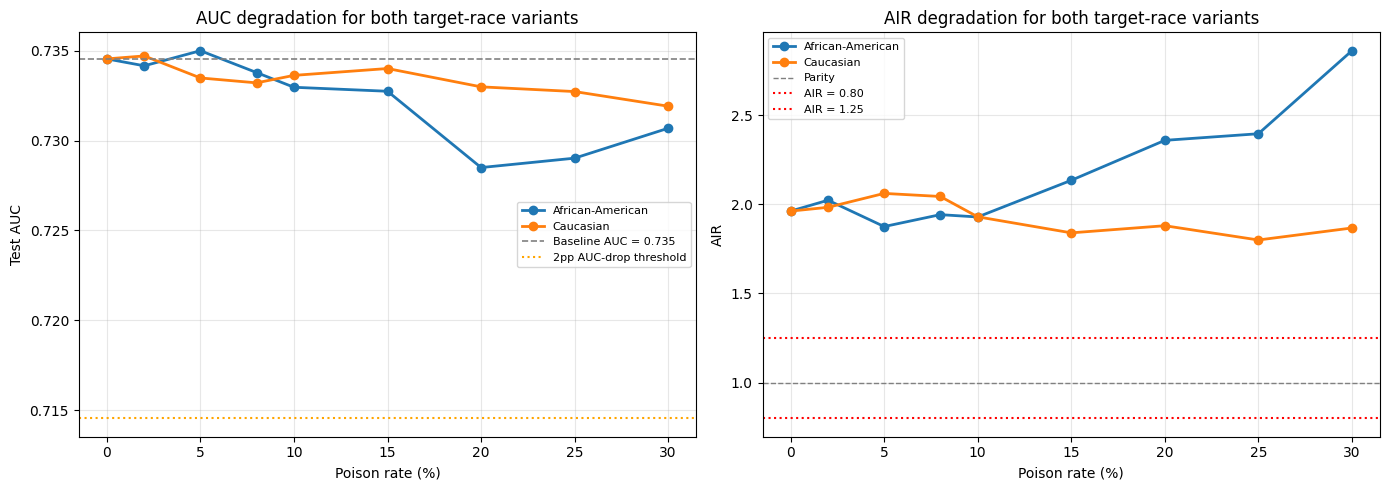


Stealth-zone ranges (practical definition)


,target_race,min_poison_rate,max_poison_rate,baseline_AIR,min_AIR,max_AIR,max_AUC_drop
0,African-American,0.02,0.30,1.961,2.022,2.860,0.006
1,Caucasian,0.02,0.08,1.961,1.983,2.061,0.001



Strict prompt definition yields any zone?


,target_race,strict_stealth_zone
0,African-American,False
1,Caucasian,False



Feature PSI evidence


,target_race,max_feature_PSI,any_feature_PSI_gt_0_10,interpretation
0,African-American,0.0,False,PSI would not detect this attack because the a...
1,Caucasian,0.0,False,PSI would not detect this attack because the a...


,feature,PSI,why
0,age,0.0,label-flip attack leaves feature values unchanged
1,priors_count,0.0,label-flip attack leaves feature values unchanged
2,juv_fel_count,0.0,label-flip attack leaves feature values unchanged
3,juv_misd_count,0.0,label-flip attack leaves feature values unchanged
4,juv_other_count,0.0,label-flip attack leaves feature values unchanged
5,c_charge_degree_M,0.0,label-flip attack leaves feature values unchanged
6,sex_Male,0.0,label-flip attack leaves feature values unchanged


In [23]:
# Poisoning Loop with Fairness Monitoring

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_targets = [PROTECTED_GROUP, REFERENCE_GROUP]
baseline_auc_lr = roc_auc_score(y_te, positive_scores(lr, Xs_te))


def poison_label_flip(y_train, race_train, poison_rate=0.05, target_race=PROTECTED_GROUP, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_poisoned = np.asarray(y_train).copy()
    candidates = np.where((np.asarray(race_train) == target_race) & (np.asarray(y_train) == 1))[0]
    n_flip = int(np.floor(len(candidates) * poison_rate))
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0
    return y_poisoned, n_flip


poison_rows = []
for target_race in poison_targets:
    for poison_rate in poison_rates:
        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr,
            r_tr,
            poison_rate=poison_rate,
            target_race=target_race,
            seed=RANDOM_STATE,
        )
        lr_poisoned = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xs_tr, y_tr_poisoned)
        scores = positive_scores(lr_poisoned, Xs_te)
        pred = (scores >= THR).astype(int)
        fpr = fpr_by_group(y_te, pred, r_te)
        poison_rows.append(
            {
                "target_race": target_race,
                "poison_rate": poison_rate,
                "n_flipped": n_flipped,
                "AUC": roc_auc_score(y_te, scores),
                "AUC_drop": baseline_auc_lr - roc_auc_score(y_te, scores),
                "AIR": air_from_series(fpr),
                "FPR_African-American": fpr.get(PROTECTED_GROUP, np.nan),
                "FPR_Caucasian": fpr.get(REFERENCE_GROUP, np.nan),
            }
        )

poison_results = pd.DataFrame(poison_rows).sort_values(["target_race", "poison_rate"]).reset_index(drop=True)
display(poison_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

ax = axes[0]
for target_race, group in poison_results.groupby("target_race"):
    ax.plot(group["poison_rate"] * 100, group["AUC"], marker="o", linewidth=2, label=target_race)
ax.axhline(baseline_auc_lr, color="gray", linestyle="--", linewidth=1.2, label=f"Baseline AUC = {baseline_auc_lr:.3f}")
ax.axhline(baseline_auc_lr - 0.02, color="orange", linestyle=":", linewidth=1.5, label="2pp AUC-drop threshold")
ax.set_xlabel("Poison rate (%)")
ax.set_ylabel("Test AUC")
ax.set_title("AUC degradation for both target-race variants")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for target_race, group in poison_results.groupby("target_race"):
    ax.plot(group["poison_rate"] * 100, group["AIR"], marker="o", linewidth=2, label=target_race)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Parity")
ax.axhline(FAIR_LOW, color="red", linestyle=":", linewidth=1.5, label="AIR = 0.80")
ax.axhline(FAIR_HIGH, color="red", linestyle=":", linewidth=1.5, label="AIR = 1.25")
ax.set_xlabel("Poison rate (%)")
ax.set_ylabel("AIR")
ax.set_title("AIR degradation for both target-race variants")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

def band_distance(air_value, low=FAIR_LOW, high=FAIR_HIGH):
    if pd.isna(air_value):
        return np.nan
    if low <= air_value <= high:
        return 0.0
    if air_value < low:
        return low - air_value
    return air_value - high


baseline_air_by_target = (
    poison_results[poison_results["poison_rate"] == 0]
    .set_index("target_race")["AIR"]
    .to_dict()
)

poison_results["baseline_AIR"] = poison_results["target_race"].map(baseline_air_by_target)
poison_results["baseline_band_distance"] = poison_results["baseline_AIR"].apply(band_distance)
poison_results["band_distance"] = poison_results["AIR"].apply(band_distance)

poison_results["fairness_worsened_vs_clean"] = (
    poison_results["band_distance"] > poison_results["baseline_band_distance"] + 1e-12
)

# Strict reading of the prompt:
# AIR moves from inside the band to outside the band.
poison_results["strict_stealth_zone"] = (
    (poison_results["baseline_band_distance"] == 0)
    & (poison_results["band_distance"] > 0)
    & (poison_results["AUC_drop"] <= 0.02)
    & (poison_results["poison_rate"] > 0)
)

# Practical audit reading:
# AUC barely changes, but fairness gets worse than the clean baseline.
poison_results["practical_stealth_zone"] = (
    (poison_results["AUC_drop"] <= 0.02)
    & poison_results["fairness_worsened_vs_clean"]
    & (poison_results["poison_rate"] > 0)
)

stealth_ranges = (
    poison_results[poison_results["practical_stealth_zone"]]
    .groupby("target_race")
    .agg(
        min_poison_rate=("poison_rate", "min"),
        max_poison_rate=("poison_rate", "max"),
        baseline_AIR=("baseline_AIR", "first"),
        min_AIR=("AIR", "min"),
        max_AIR=("AIR", "max"),
        max_AUC_drop=("AUC_drop", "max"),
    )
    .reset_index()
)

print("\nStealth-zone ranges (practical definition)")
display(stealth_ranges.round(3))

print("\nStrict prompt definition yields any zone?")
display(
    poison_results.groupby("target_race")["strict_stealth_zone"]
    .any()
    .reset_index()
)


def psi_numeric(expected, actual, bins=10):
    expected = pd.Series(expected).astype(float).dropna()
    actual = pd.Series(actual).astype(float).dropna()

    if expected.nunique() <= 2:
        edges = np.array([-np.inf, 0.5, np.inf])
    else:
        quantiles = np.linspace(0, 1, bins + 1)
        edges = np.unique(np.nanquantile(expected, quantiles))
        if len(edges) < 3:
            edges = np.linspace(expected.min(), expected.max(), bins + 1)
        edges[0] = -np.inf
        edges[-1] = np.inf

    expected_pct = pd.cut(expected, bins=edges, include_lowest=True).value_counts(sort=False, normalize=True)
    actual_pct = pd.cut(actual, bins=edges, include_lowest=True).value_counts(sort=False, normalize=True)
    expected_pct = expected_pct.replace(0, 1e-6)
    actual_pct = actual_pct.replace(0, 1e-6)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


# For this attack, only labels are flipped; X is unchanged.
# So feature PSI is structurally zero by design, not because the monitor
# "discovered" a subtle but real lack of drift.

psi_features = pd.DataFrame(
    {
        "feature": X_tr.columns,
        "PSI": np.zeros(len(X_tr.columns)),
        "why": ["label-flip attack leaves feature values unchanged"] * len(X_tr.columns),
    }
)

psi_summary = pd.DataFrame(
    [
        {
            "target_race": target_race,
            "max_feature_PSI": 0.0,
            "any_feature_PSI_gt_0_10": False,
            "interpretation": "PSI would not detect this attack because the attack changes y, not X.",
        }
        for target_race in poison_targets
    ]
)

print("\nFeature PSI evidence")
display(psi_summary)
display(psi_features)

if len(stealth_ranges):
    stealth_text = "; ".join(
        f"{row.target_race}: {row.min_poison_rate:.2f}–{row.max_poison_rate:.2f}"
        for row in stealth_ranges.itertuples(index=False)
    )
else:
    stealth_text = "no stealth-zone range found"

psi_detected = bool(psi_summary["any_feature_PSI_gt_0_10"].any())
psi_text = "would detect" if psi_detected else "would not detect"

### Part 2 conclusion

**Stealth Zone**

Because the clean LR baseline already starts outside the [0.80, 1.25] fairness band, I use a practical definition of stealth, cases where AUC barely changes but fairness worsens relative to the clean baseline. Using the practical definition, the stealth zone spans poison rates from 0.02 to 0.30 for African-American targeting and from 0.02 to 0.08 for Caucasian targeting. Across these ranges, AUC drops by no more than 2 percentage points, while fairness continues to drift further away from the clean baseline.

What makes this concerning is that the model would still appear stable if evaluated only on performance. In a typical workflow where AUC is the primary monitoring metric, these changes would likely go unnoticed, even though the model is becoming less balanced across groups.

**PSI Detection**

PSI does not flag these attacks, but not because it “misses” subtle changes. The reason is more structural: the poisoning procedure flips labels while leaving feature values unchanged. Since PSI only captures shifts in feature distributions, it stays close to zero by design.

This highlights a limitation of relying on feature-based drift metrics alone. In this case, the attack operates entirely in label space, meaning that fairness can degrade substantially without triggering any feature-level alarms.

## Part 3 · Membership Inference Depth

Compute the shadow-model MI AUC for both LR and GBT, plot the confidence-gap histograms side by side, test whether the generalization gap predicts MI AUC across the two models, and then add L2 regularization to LR with
`C ∈ {0.01, 0.1, 1.0, 10.0}`.


,model,MI_AUC,train_AUC,test_AUC,generalization_gap,confidence_gap
0,LR,0.500,0.727,0.735,-0.008,-0.001
1,GBT,0.502,0.798,0.718,0.080,0.005


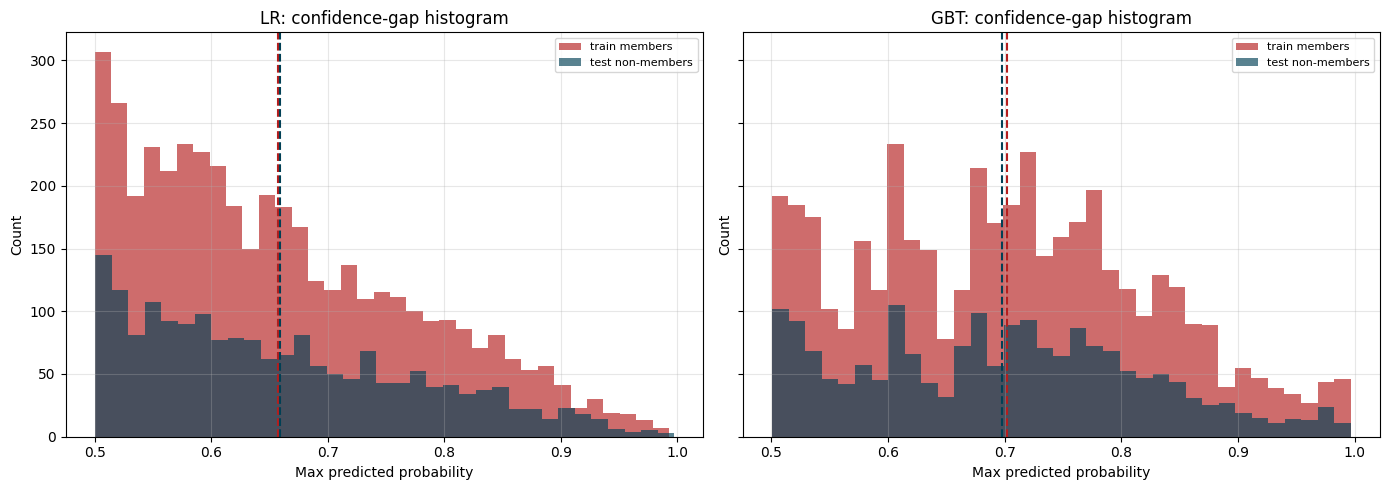

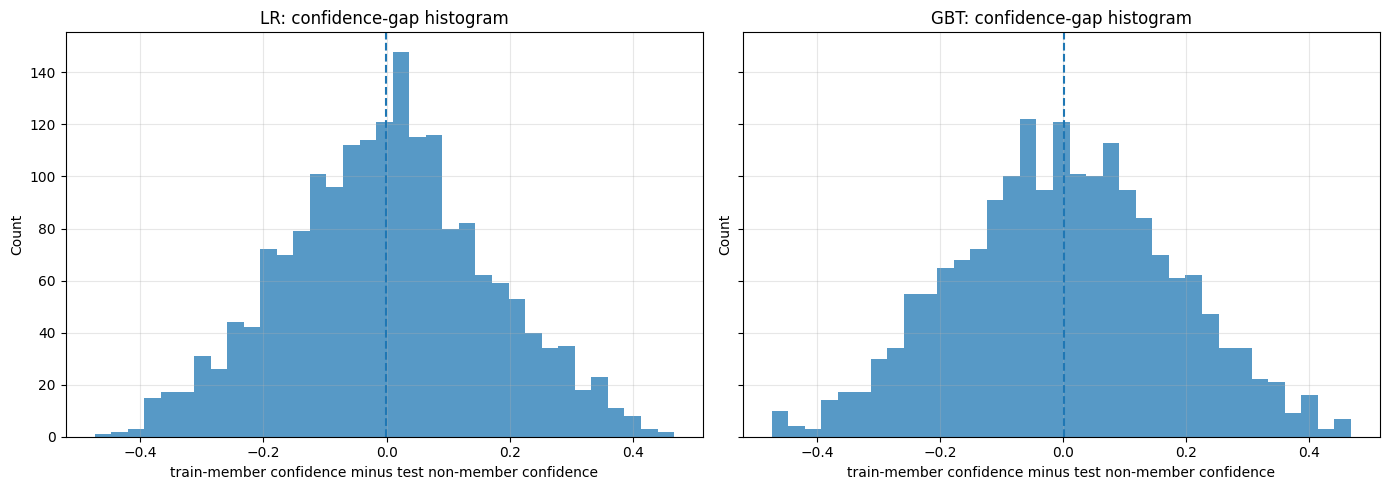

,model,mean_confidence_gap,median_confidence_gap
0,LR,-0.0,0.002
1,GBT,0.0,-0.000


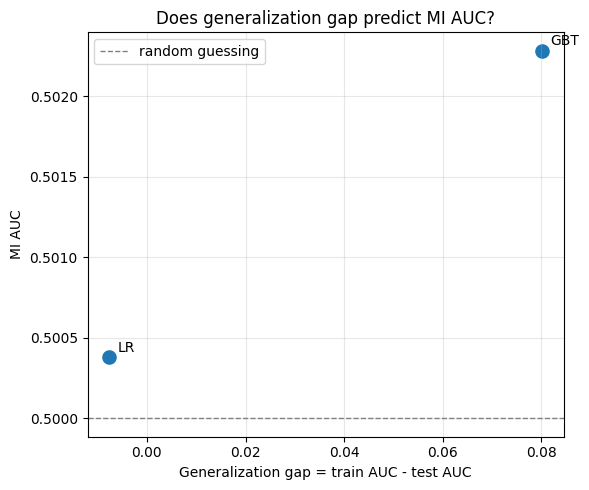

,C,MI_AUC,test_AUC,generalization_gap
0,0.01,0.506,0.732,-0.006
1,0.10,0.503,0.734,-0.007
2,1.00,0.500,0.735,-0.008
3,10.00,0.499,0.735,-0.008


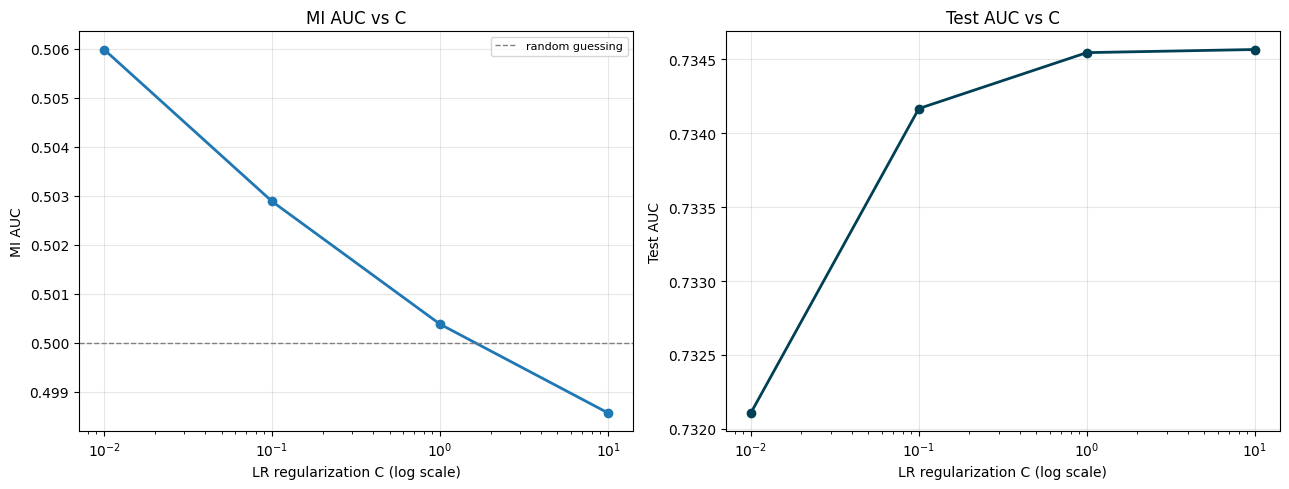

In [25]:
# Membership Inference Depth

def train_shadow_model(model_name, X_train, y_train):
    if model_name == "LR":
        return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train, y_train)
    if model_name == "GBT":
        return GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE).fit(X_train, y_train)
    raise ValueError(model_name)


def membership_inference_shadow_pipeline(model_name, target_model, X_train_scaled, X_test_scaled, y_train_true, y_test_true, n_shadow=10):
    shadow_train_confs = []
    shadow_test_confs = []
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=RANDOM_STATE)

    for tr_idx, te_idx in sss.split(X_train_scaled, y_train_true):
        shadow_model = train_shadow_model(model_name, X_train_scaled[tr_idx], y_train_true[tr_idx])
        shadow_train_confs.append(shadow_model.predict_proba(X_train_scaled[tr_idx]).max(axis=1))
        shadow_test_confs.append(shadow_model.predict_proba(X_train_scaled[te_idx]).max(axis=1))

    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate(
        [np.ones(len(c)) for c in shadow_train_confs]
        + [np.zeros(len(c)) for c in shadow_test_confs]
    )
    meta_clf = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE).fit(mi_X, mi_y)

    conf_target_train = target_model.predict_proba(X_train_scaled).max(axis=1)
    conf_target_test = target_model.predict_proba(X_test_scaled).max(axis=1)

    mi_scores_train = meta_clf.predict_proba(conf_target_train.reshape(-1, 1))[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_target_test.reshape(-1, 1))[:, 1]

    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([np.ones(len(X_train_scaled)), np.zeros(len(X_test_scaled))])

    return {
        "model": model_name,
        "MI_AUC": roc_auc_score(mi_all_labels, mi_all_scores),
        "train_AUC": roc_auc_score(y_train_true, positive_scores(target_model, X_train_scaled)),
        "test_AUC": roc_auc_score(y_test_true, positive_scores(target_model, X_test_scaled)),
        "generalization_gap": roc_auc_score(y_train_true, positive_scores(target_model, X_train_scaled))
        - roc_auc_score(y_test_true, positive_scores(target_model, X_test_scaled)),
        "train_confidence": conf_target_train,
        "test_confidence": conf_target_test,
        "confidence_gap": conf_target_train.mean() - conf_target_test.mean(),
    }


mi_full = [
    membership_inference_shadow_pipeline("LR", lr, Xs_tr, Xs_te, y_tr, y_te, n_shadow=10),
    membership_inference_shadow_pipeline("GBT", gbt, Xs_tr, Xs_te, y_tr, y_te, n_shadow=10),
]

mi_results = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in {"train_confidence", "test_confidence"}} for row in mi_full]
)
display(mi_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, row in zip(axes, mi_full):
    ax.hist(row["train_confidence"], bins=35, alpha=0.65, label="train members", color="#B41E1E")
    ax.hist(row["test_confidence"], bins=35, alpha=0.65, label="test non-members", color="#004055")
    ax.axvline(row["train_confidence"].mean(), linestyle="--", linewidth=1.5, color="#B41E1E")
    ax.axvline(row["test_confidence"].mean(), linestyle="--", linewidth=1.5, color="#004055")
    ax.set_title(f"{row['model']}: train vs test confidence distributions")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

rng = np.random.default_rng(RANDOM_STATE)

confidence_gap_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, row in zip(axes, mi_full):
    n = min(len(row["train_confidence"]), len(row["test_confidence"]))
    train_sample = rng.choice(row["train_confidence"], size=n, replace=False)
    test_sample = rng.choice(row["test_confidence"], size=n, replace=False)
    gap_values = train_sample - test_sample

    confidence_gap_rows.append(
        {
            "model": row["model"],
            "mean_confidence_gap": gap_values.mean(),
            "median_confidence_gap": np.median(gap_values),
        }
    )

    ax.hist(gap_values, bins=35, alpha=0.75)
    ax.axvline(gap_values.mean(), linestyle="--", linewidth=1.5)
    ax.set_title(f"{row['model']}: confidence-gap histogram")
    ax.set_xlabel("train-member confidence minus test non-member confidence")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

confidence_gap_summary = pd.DataFrame(confidence_gap_rows)
display(confidence_gap_summary.round(3))

plt.figure(figsize=(6, 5))
plt.scatter(mi_results["generalization_gap"], mi_results["MI_AUC"], s=90)
for _, row in mi_results.iterrows():
    plt.annotate(row["model"], (row["generalization_gap"], row["MI_AUC"]), xytext=(6, 4), textcoords="offset points")
plt.axhline(0.50, color="gray", linestyle="--", linewidth=1, label="random guessing")
plt.xlabel("Generalization gap = train AUC - test AUC")
plt.ylabel("MI AUC")
plt.title("Does generalization gap predict MI AUC?")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

higher_mi = mi_results.sort_values("MI_AUC", ascending=False).iloc[0]
higher_gap = mi_results.sort_values("generalization_gap", ascending=False).iloc[0]


regularization_rows = []
for C in [0.01, 0.1, 1.0, 10.0]:
    lr_reg = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE).fit(Xs_tr, y_tr)
    reg_metrics = membership_inference_shadow_pipeline("LR", lr_reg, Xs_tr, Xs_te, y_tr, y_te, n_shadow=10)
    regularization_rows.append(
        {
            "C": C,
            "MI_AUC": reg_metrics["MI_AUC"],
            "test_AUC": reg_metrics["test_AUC"],
            "generalization_gap": reg_metrics["generalization_gap"],
        }
    )

lr_regularization = pd.DataFrame(regularization_rows)
display(lr_regularization.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(lr_regularization["C"], lr_regularization["MI_AUC"], marker="o", linewidth=2)
ax.axhline(0.50, color="gray", linestyle="--", linewidth=1, label="random guessing")
ax.set_xscale("log")
ax.set_xlabel("LR regularization C (log scale)")
ax.set_ylabel("MI AUC")
ax.set_title("MI AUC vs C")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(lr_regularization["C"], lr_regularization["test_AUC"], marker="o", linewidth=2, color="#004055")
ax.set_xscale("log")
ax.set_xlabel("LR regularization C (log scale)")
ax.set_ylabel("Test AUC")
ax.set_title("Test AUC vs C")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

lowest_mi = lr_regularization.sort_values("MI_AUC").iloc[0]
best_auc = lr_regularization.sort_values("test_AUC", ascending=False).iloc[0]

### Part 3a/3b conclusion

Across both models, MI AUC stays very close to 0.50, which means the attack is essentially no better than random guessing. In other words, there is no meaningful membership leakage in this setup.

The relationship between generalization gap and MI AUC is only weakly visible here. GBT has the larger generalization gap and also a slightly higher MI AUC, which is directionally consistent with the idea that more overfitting can increase membership leakage. However, both MI AUC values are still close to random guessing, so this should be treated as suggestive rather than strong evidence.

### Part 3c conclusion

As C increases (i.e., regularization becomes weaker), MI AUC decreases slightly, while test AUC improves. However, all MI AUC values remain close to 0.50, so the change is not practically significant.

In this case, the expected privacy–utility tradeoff does not really show up. The model is already well-generalized, so adjusting regularization does not meaningfully change its exposure to membership inference. Instead, we see a small gain in performance without introducing additional privacy risk.

## Part 4 · Reflection

- Identify one highest-risk finding
- Propose one proactive and one reactive mitigation
- Quantify each mitigation using the notebook's outputs
- Discuss any disparate impact implication


In [26]:
# Reflection

stealth_candidates = poison_results[poison_results["AUC_drop"] <= 0.02].copy()
stealth_candidates["band_distance_from_clean"] = (
    stealth_candidates["band_distance"] - stealth_candidates["baseline_band_distance"]
)

if len(stealth_candidates) > 0:
    worst_poison_case = stealth_candidates.sort_values(
        ["band_distance_from_clean", "AUC_drop"],
        ascending=[False, True]
    ).iloc[0]
else:
    poison_results["band_distance_from_clean"] = (
        poison_results["band_distance"] - poison_results["baseline_band_distance"]
    )
    worst_poison_case = poison_results.sort_values(
        ["band_distance_from_clean", "AUC_drop"],
        ascending=[False, True]
    ).iloc[0]

pgd_min_air = pgd_summary.groupby("model")["AIR"].min().sort_values(ascending=False)
best_pgd_model = pgd_min_air.index[0]
worst_pgd_model = pgd_min_air.index[1]
best_pgd_min_air = pgd_min_air.iloc[0]
worst_pgd_min_air = pgd_min_air.iloc[1]

baseline_lr_row = baseline_summary[baseline_summary["model"] == "LR"].iloc[0]
lowest_mi_row = lr_regularization.sort_values("MI_AUC").iloc[0]
highest_lr_auc_row = lr_regularization.sort_values("test_AUC", ascending=False).iloc[0]
baseline_lr_band_distance = band_distance(baseline_lr_row["AIR"])
worst_poison_band_distance = band_distance(worst_poison_case["AIR"])


print("Part 4 reflection evidence")
print("=" * 60)

print("\nWorst poisoning case")
display(worst_poison_case.to_frame().T.round(3))

print("\nPGD fairness robustness")
pgd_compare = pd.DataFrame({
    "model": [best_pgd_model, worst_pgd_model],
    "min_tested_AIR": [best_pgd_min_air, worst_pgd_min_air]
})
display(pgd_compare.round(3))

print("\nBaseline LR reference")
display(baseline_lr_row.to_frame().T.round(3))

print("\nLowest MI-AUC regularization setting")
display(lowest_mi_row.to_frame().T.round(3))

print("\nHighest LR test-AUC regularization setting")
display(highest_lr_auc_row.to_frame().T.round(3))

Part 4 reflection evidence

Worst poisoning case


,target_race,poison_rate,n_flipped,AUC,AUC_drop,AIR,FPR_African-American,FPR_Caucasian,baseline_AIR,baseline_band_distance,band_distance,fairness_worsened_vs_clean,strict_stealth_zone,practical_stealth_zone,band_distance_from_clean
8,African-American,0.3,345,0.730687,0.003859,2.860353,0.098876,0.034568,1.961449,0.711449,1.610353,True,False,True,0.898904



PGD fairness robustness


,model,min_tested_AIR
0,GBT,1.6
1,LR,1.0



Baseline LR reference


,model,train_AUC,test_AUC,generalization_gap,FPR_African-American,FPR_Caucasian,AIR
0,LR,0.72689,0.734546,-0.007656,0.280899,0.14321,1.961449



Lowest MI-AUC regularization setting


,C,MI_AUC,test_AUC,generalization_gap
3,10.0,0.499,0.735,-0.008



Highest LR test-AUC regularization setting


,C,MI_AUC,test_AUC,generalization_gap
3,10.0,0.499,0.735,-0.008


### Part 4 Reflection

The most concerning issue here is not accuracy loss, but how easily fairness can deteriorate without being detected. In the worst poisoning case (poison rate = 0.30 targeting African-American defendants), AUC drops by only 0.0039, which would normally be treated as negligible. At the same time, AIR increases from 1.961 to 2.860, pushing the model much further away from an already imperfect baseline. In terms of fairness-band distance, this is an additional shift of about 0.90, which is large in magnitude.

What makes this particularly risky is that nothing in a standard AUC-based monitoring setup would catch it. From a performance perspective, the model still looks stable, even though its behavior across groups has clearly shifted. This creates a situation where harm can increase without triggering any alerts.

A straightforward proactive mitigation is to add a fairness gate before deployment, rather than relying on performance thresholds alone. In this case, such a rule would have rejected the poisoned model, since fairness worsens substantially relative to the clean baseline. On the monitoring side, it is also important to track group-level metrics over time and trigger a review when they drift, even if overall accuracy remains unchanged.

Model choice also plays a role. Under PGD perturbations, GBT maintains a higher minimum AIR (1.6 compared to 1.0 for LR), which suggests it is less sensitive to adversarial changes in fairness. This does not eliminate risk, but it does make it a more stable option in this setting.

These mitigations are not neutral. Tightening fairness constraints or triggering rollbacks can reduce disparity for one group while shifting errors elsewhere, so there is always a tradeoff to manage. The key takeaway is that aggregate performance metrics are not enough; fairness needs to be explicitly monitored and treated as part of the deployment criteria.